In [2]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import MinMaxScaler
from sklearn.preprocessing import RobustScaler
from sklearn.preprocessing import QuantileTransformer

# Assuming df is your DataFrame with 7 features and 1 outcome label
# Replace 'your_dataset.csv' with your actual dataset file or provide the DataFrame directly
# df = pd.read_csv('your_dataset.csv')

# Plotting the distribution curves for each feature


In [3]:
data_path = "data/processed_biomarkers_features.csv"
data = pd.read_csv(data_path)
data.shape

(41, 15)

In [4]:
data.columns

Index(['AKT1', 'EGFR', 'TP53', 'CDKN2A', 'IDH1', 'MGMT', 'PTEN', 'TERT',
       'CDKN2B', 'IDH2', 'PROM1', 'CD68', 'PRR15', 'SLC25A41', 'Outcome'],
      dtype='object')

In [5]:
#data splitting Pipeline,  labels and features
cols_labels = data.columns.tolist()
cols_labels.pop(-1)

'Outcome'

In [7]:
data_features = pd.read_csv(data_path, usecols = cols_labels)
data_labels = pd.read_csv(data_path, usecols = ['Outcome'])

In [8]:
data_features_scaled = StandardScaler().fit_transform(data_features)

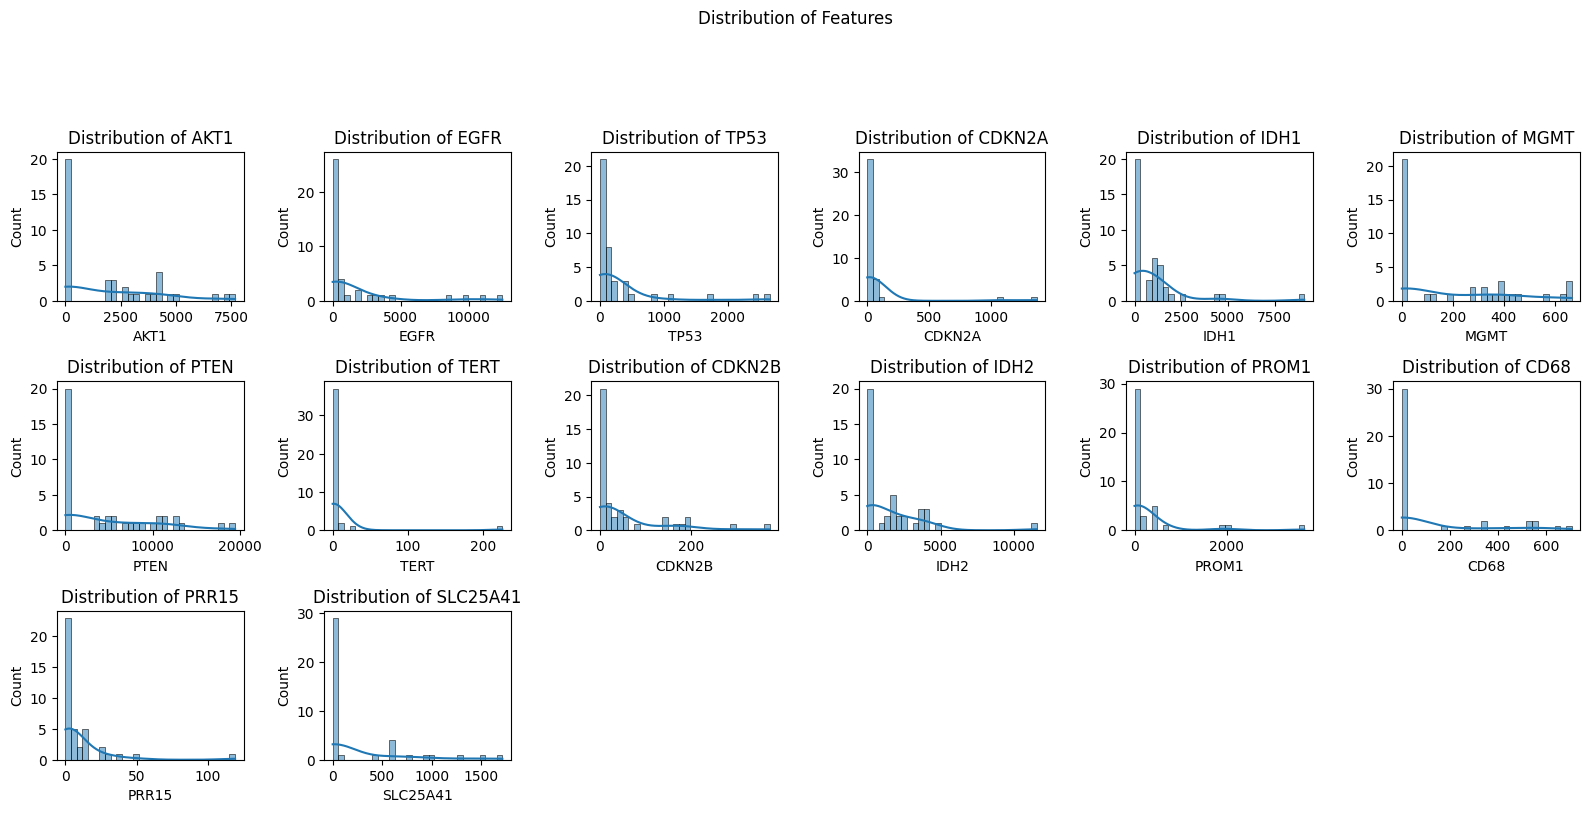

In [9]:
#......................................................................ORIGINAL DATA DISTRIBUTION
df = data_features
# Set up subplots
fig, axes = plt.subplots(nrows=5, ncols=6, figsize=(16, 12))
fig.suptitle('Distribution of Features', y=1.02)

# Flatten the 2D array of subplots for easier indexing
axes = axes.flatten()

# Plot the distribution of each feature in a separate subplot
for i, column in enumerate(df.columns):
    if i < len(axes):  # Check if there are more subplots than features
        sns.histplot(df[column], kde=True, ax=axes[i], bins=30)
        axes[i].set_title(f'Distribution of {column}')
    else:
        break  # Break the loop if we have plotted all features

# Remove any empty subplots if the number of features is less than 30
for i in range(len(df.columns), len(axes)):
    fig.delaxes(axes[i])

# Adjust layout to prevent overlap of titles
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

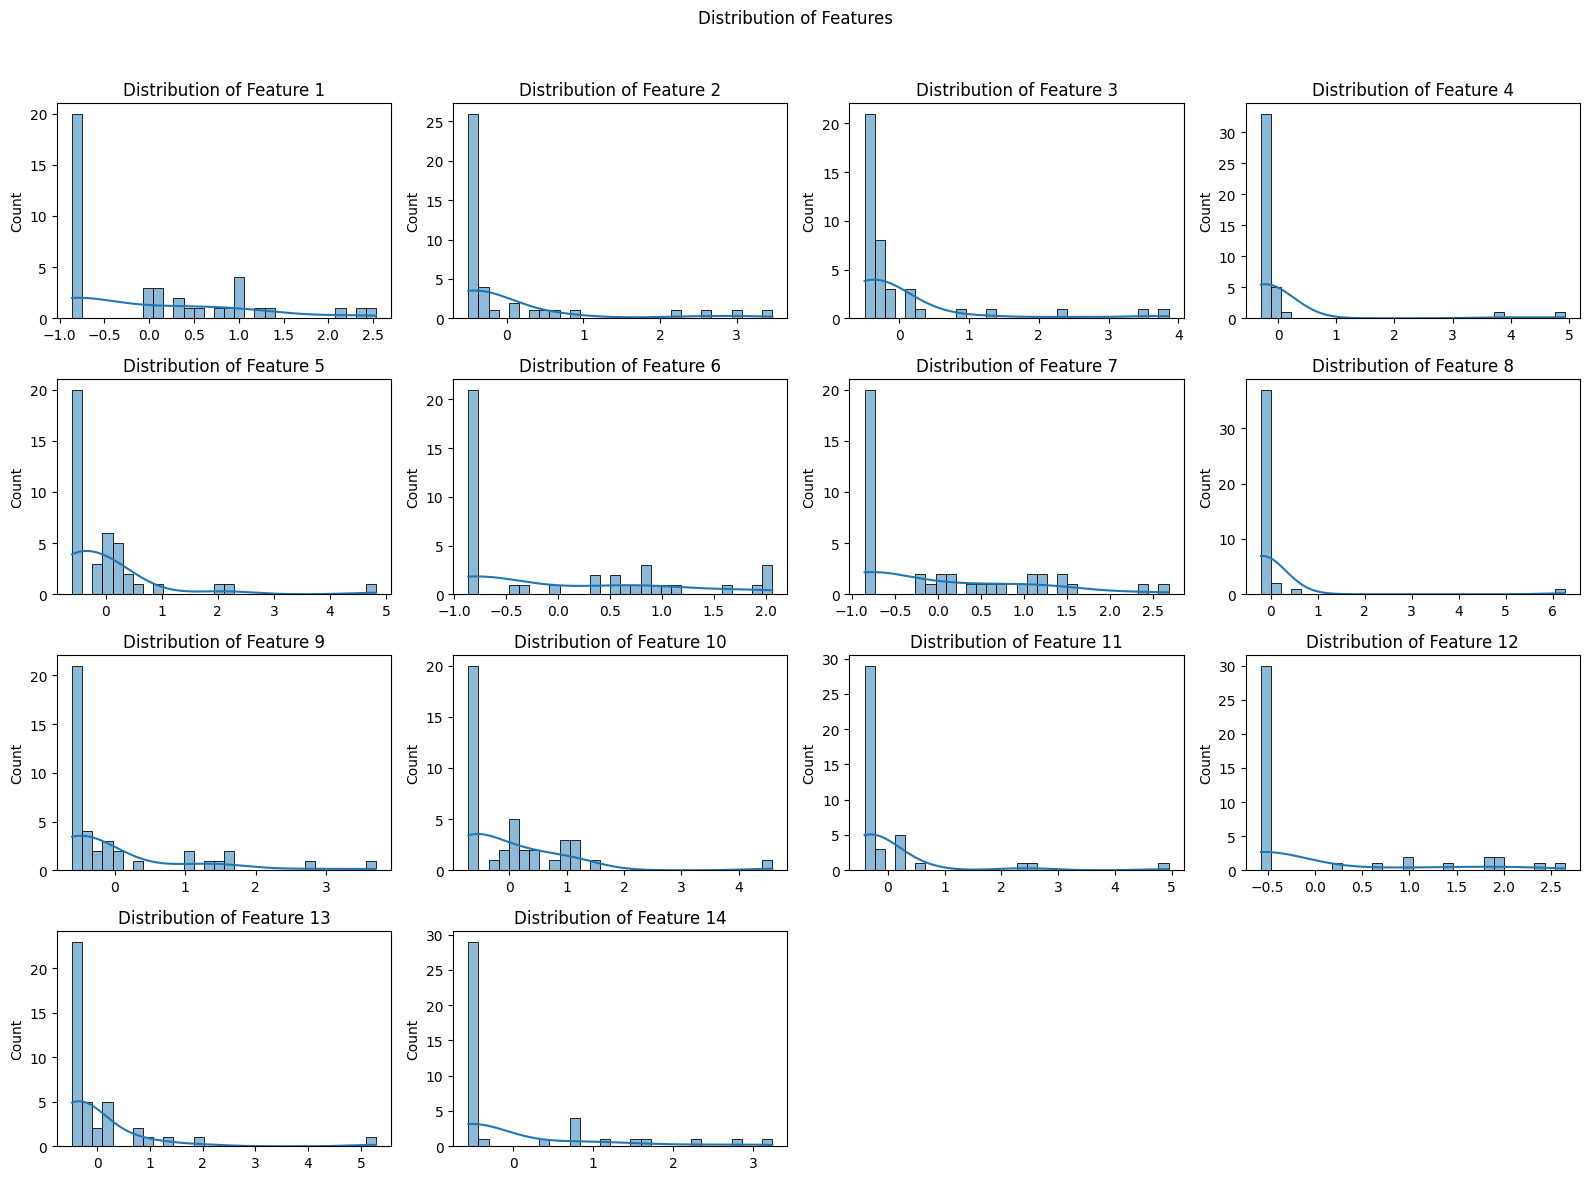

In [10]:
#...............................................................................SCALED DATA DISTRIBUTION
your_data = data_features_scaled
fig, axes = plt.subplots(nrows=4, ncols=4, figsize=(16, 12))
fig.suptitle('Distribution of Features')

# Flatten the 2D array of subplots for easier indexing
axes = axes.flatten()

# Plot the distribution of each feature in a separate subplot
for i in range(min(your_data.shape[1], len(axes))):  # Iterate over columns (features)
    sns.histplot(your_data[:, i], kde=True, ax=axes[i], bins=30)
    axes[i].set_title(f'Distribution of Feature {i + 1}')

# Remove any empty subplots if the number of features is less than 16
for i in range(your_data.shape[1], len(axes)):
    fig.delaxes(axes[i])

# Adjust layout to prevent overlap of titles
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

In [11]:
#df = data_features_scaled
df = pd.DataFrame(data_features_scaled, columns=cols_labels)

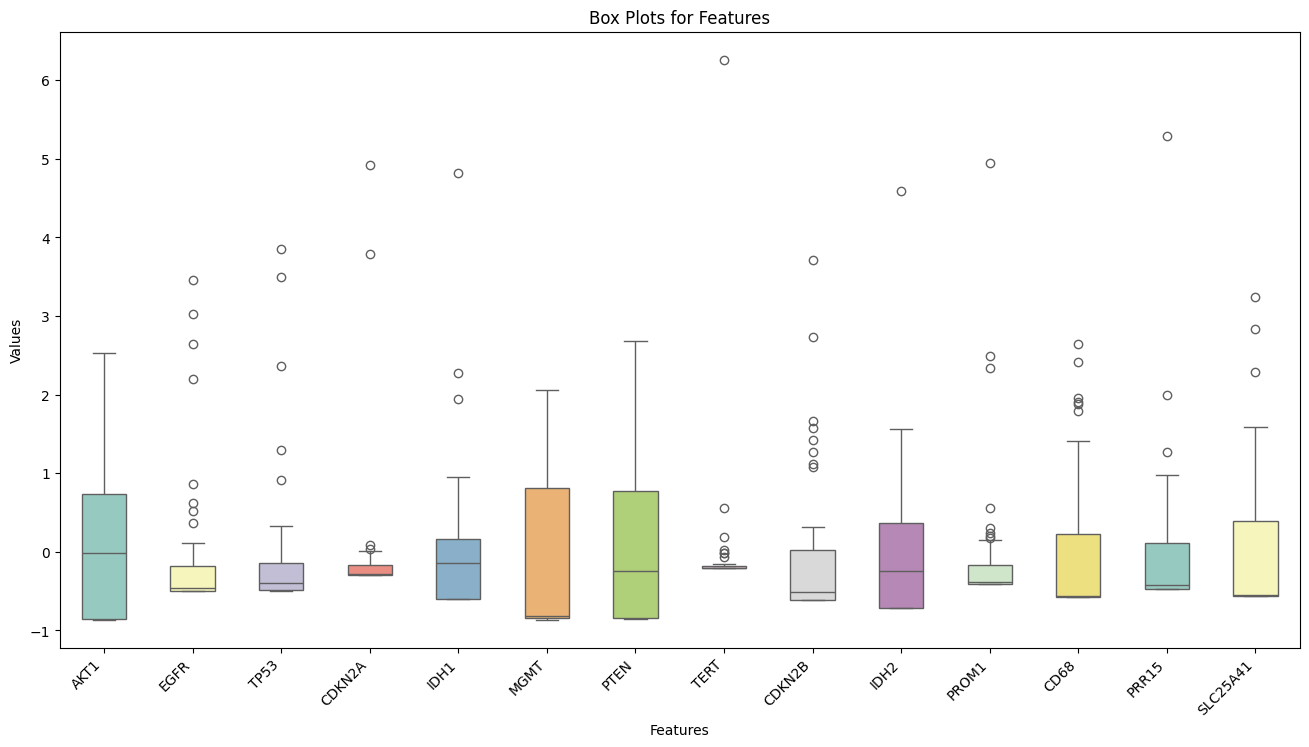

In [12]:
# Set up the size of the plot

plt.figure(figsize=(16, 8))

# Draw box plots for each feature
sns.boxplot(data=df, width=0.5, palette='Set3')

# Set plot labels and title
plt.title('Box Plots for Features')
plt.xlabel('Features')
plt.ylabel('Values')

# Rotate x-axis labels for better readability
plt.xticks(rotation=45, ha='right')

# Show the plot
plt.show()

In [138]:
outlier_rows = []
for column in df.columns:
    q1 = df[column].quantile(0.25)
    q3 = df[column].quantile(0.75)
    iqr = q3 - q1
    lower_bound = q1 - 1.5 * iqr
    upper_bound = q3 + 1.5 * iqr
    outliers = df[(df[column] < lower_bound) | (df[column] > upper_bound)]
    outlier_rows.extend(outliers.index.tolist())

# Remove duplicate row numbers
outlier_rows = list(set(outlier_rows))

# Print the row numbers containing outliers
print("Rows containing outliers:", outlier_rows)

# Now you can remove the rows with outliers from your DataFrame
data_without_outliers = data.drop(outlier_rows)
df_without_outiers = df.drop(outlier_rows)

Rows containing outliers: [192]


In [139]:
data_without_outliers.to_csv("data/noOutliers-data4.csv", index=False)

In [140]:
#data splitting Pipeline,  labels and features
data = pd.read_csv("data/noOutliers-data4.csv")
cols_labels = data.columns.tolist()
cols_labels.pop(-1)

data_features = pd.read_csv("data/noOutliers-data4.csv", usecols = cols_labels)
data_labels = pd.read_csv("data/noOutliers-data4.csv", usecols = ['Outcomes'])
data_features_scaled = StandardScaler().fit_transform(data_features)
#df = data_features_scaled
df = pd.DataFrame(data_features_scaled, columns=cols_labels)

In [141]:
df.shape

(369, 18)

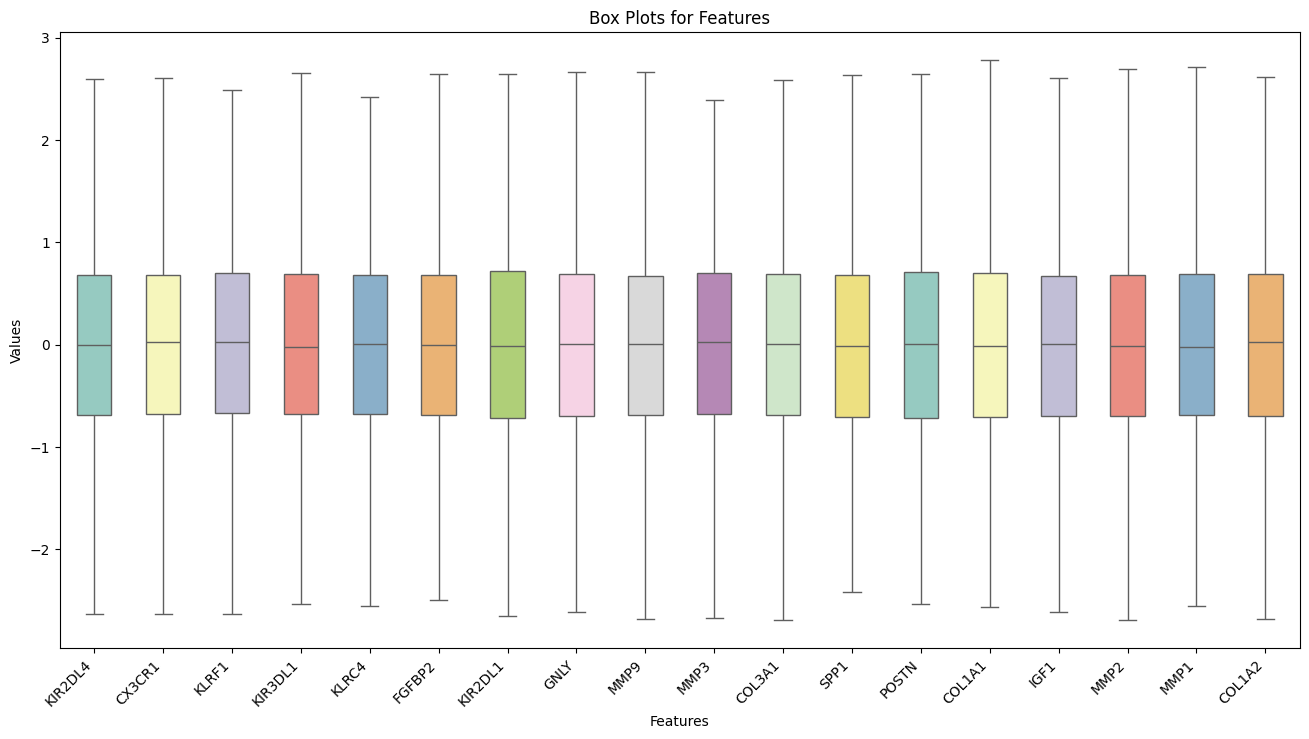

In [142]:
# Set up the size of the plot after outliers are removed

plt.figure(figsize=(16, 8))

# Draw box plots for each feature
sns.boxplot(data=df, width=0.5, palette='Set3')

# Set plot labels and title
plt.title('Box Plots for Features')
plt.xlabel('Features')
plt.ylabel('Values')

# Rotate x-axis labels for better readability
plt.xticks(rotation=45, ha='right')

# Show the plot
plt.show()

In [63]:
df_without_outliers.shape

(369, 18)

In [64]:
#remove corresponding labels of removed outliers
outcomes= data['Outcomes']
# Drop corresponding rows from the outcomes Series
outcomes_without_outliers = outcomes.drop(outlier_rows)

# Now you can join the outcomes with the resulting DataFrame
result_df = df_without_outliers.join(outcomes_without_outliers, how='inner')

In [65]:
result_df

,KIR2DL4,CX3CR1,KLRF1,KIR3DL1,KLRC4,FGFBP2,KIR2DL1,GNLY,MMP9,MMP3,COL3A1,SPP1,POSTN,COL1A1,IGF1,MMP2,MMP1,COL1A2,Outcomes
0,1.205701,-0.450090,-1.107712,-0.520853,0.529055,-0.398528,1.129803,1.214486,-0.338911,1.135329,-0.782616,0.116118,0.459282,-0.310594,-1.025663,0.369956,0.427044,0.706514,1
1,0.986622,-0.190709,-0.866457,-0.410305,0.790106,-0.815658,0.518546,1.707554,0.032518,0.064664,-0.208567,-0.097336,0.311752,1.183628,-0.911660,0.950167,0.405991,1.275884,1
2,1.016563,1.426969,0.459162,-0.417073,-0.695809,0.185274,-0.857634,-0.668341,0.146698,0.638398,0.593743,0.517400,-0.174824,0.227630,-1.076975,0.702132,0.550001,-0.111295,1
3,1.784813,-0.376686,0.571640,-1.507307,0.798690,-0.666429,-0.568279,-0.245598,-0.385625,0.211988,0.691455,1.445536,-0.938109,-0.611771,1.294850,-0.217602,1.476106,-0.086238,1
4,1.555044,0.045222,-0.966281,-0.390101,2.095715,0.276774,1.086139,0.425197,0.781427,0.821076,0.007603,1.039444,1.622750,0.815321,0.800688,0.940800,-0.487689,-0.130118,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
365,-0.672273,-0.532779,-0.619397,0.460821,1.176155,-0.556875,-0.193280,1.622070,-0.279762,0.001054,0.918566,0.848124,0.272704,1.363385,1.268311,1.401111,-0.425174,0.248108,1
366,-1.135222,-0.463666,0.209985,-0.067965,-1.059872,1.237485,-0.772083,1.754895,-0.765575,0.231418,0.013749,0.732483,-0.049209,0.140816,-0.186286,0.573199,-0.069250,1.526591,1
367,-0.063446,-1.002969,-0.687085,-0.080539,-1.312301,-1.110352,-0.797241,0.359067,0.335131,-1.069014,0.130946,1.260248,0.494025,-0.109693,0.513312,0.774596,1.307957,0.152129,1
368,-0.112950,-0.740862,-1.198451,-0.629915,1.401063,-1.713882,-0.127380,1.923648,-2.013536,-0.068991,-0.928065,-0.084465,-0.225640,-0.596563,-1.224592,-0.818008,0.943130,0.840072,1


In [66]:
result_df.to_csv("data/noOutliers-completely.csv", index=False)

In [ ]:
#................................................................ DROPING FEATURES WITH TOO MANY OUTLIERS

In [13]:


#to select specific columns
cols2sel = ['AKT1', 'MGMT', 'PTEN','Outcome']
#cols2sel = cols2sel = ['PIP4K2B', 'PCGF2', 'MYO19', 'GGNBP2', 'C17orf78','GOLGA6L10', 'MRPL45','TADA2A','Outcomes']
#cols2sel = ['PIP4K2B', 'PCGF2', 'MYO19', 'GGNBP2' , 'DUSP14', 'HIST1H3F','PSMB3', 'Outcomes']
#cols2sel = ['PIP4K2B', 'PCGF2', 'MYO19', 'GGNBP2', 'Outcomes']

#cols2sel = ['PIP4K2B', 'PCGF2', 'MYO19', 'GGNBP2', 'Outcomes']

data_sel = pd.read_csv(data_path, usecols = cols2sel)
data_sel.shape
#to drop

#cols2drop = ['IRF7', 'PRKG1', 'AHNAK2', 'BRWD1', 'NAT8L', 'ZNF829', 'ATP6V0C', 'IFITM1', 'PAGR1']
#cols2drop = ['IRF7', 'PRKG1', 'AHNAK2', 'BRWD1', 'NAT8L', 'ZNF829', 'ATP6V0C', 'IFITM1', 'PAGR1', 'FAM131C', 'PDE6G', 'EVI2B', 'ZNF267']
#data_org = pd.read_csv(data_path)
#data_dropped = data_org.drop(cols2drop, axis=1)
#data_dropped.shape

(41, 4)

In [14]:
data_sel.head(17)

,AKT1,MGMT,PTEN,Outcome
0,6,1,48,1
1,10,2,53,1
2,6,7,33,0
3,8,9,56,0
4,5,0,34,1
5,9,1,33,1
6,19,4,85,0
7,7,10,79,0
8,7,8,54,0
9,2,2,16,0


In [15]:
data_sel.to_csv("data/outliers-none.csv", index = False)